Käytin tehtävässä Inside Airbnb dataa Lontoosta (listings.csv). (Lataa listings.csv Lontoolle https://insideairbnb.com/get-the-data/).

In [1]:
import pandas as pd
import seaborn as sns

In [ ]:
# Luetaan data dataframeen
data = pd.read_csv("data/listings.csv")
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,13913,Holiday London DB Room Let-on going,54730,Alina,NaN,Islington,51.56861,-0.11270,Private room,70.0,1,55,2025-08-21,0.30,2,331,10,NaN
1,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,NaN,Kensington and Chelsea,51.48780,-0.16813,Entire home/apt,149.0,4,97,2025-04-05,0.51,1,199,1,NaN
2,17402,Very Central Modern 3-Bed/2 Bath By Oxford St W1,67564,Liz,NaN,Westminster,51.52195,-0.14094,Entire home/apt,411.0,3,56,2024-02-19,0.32,2,80,0,NaN
3,24328,Battersea live/work artist house,41759,Joe,NaN,Wandsworth,51.47072,-0.16266,Entire home/apt,NaN,7,95,2025-07-05,0.53,1,294,1,NaN
4,36274,Bright 1 bedroom apt off brick lane in Shoreditch,133271,Hendryks,NaN,Tower Hamlets,51.52322,-0.06979,Entire home/apt,210.0,5,15,2025-09-06,0.09,2,323,6,NaN


In [3]:
# Katsotaan datan muoto, montako riviä ja saraketta
rows, columns = data.shape
rows, columns

(96871, 18)

In [4]:
# Ylempää nähdään, että datassa on joillakin sarakkeilla paljon NaN-arvoja, tutkitaan tarkemmin
data.isna().sum()

id                                    0
name                                  0
host_id                               0
host_name                            43
neighbourhood_group               96871
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                             34908
minimum_nights                        0
number_of_reviews                     0
last_review                       24122
reviews_per_month                 24122
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           96871
dtype: int64

In [5]:
# Poistetaan sarakkeet, joissa kaikki arvot on NaN (license ja neigborhood_group)
data = data.drop(["neighbourhood_group", "license"], axis = 1)
data

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,13913,Holiday London DB Room Let-on going,54730,Alina,Islington,51.568610,-0.112700,Private room,70.0,1,55,2025-08-21,0.30,2,331,10
1,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,Kensington and Chelsea,51.487800,-0.168130,Entire home/apt,149.0,4,97,2025-04-05,0.51,1,199,1
2,17402,Very Central Modern 3-Bed/2 Bath By Oxford St W1,67564,Liz,Westminster,51.521950,-0.140940,Entire home/apt,411.0,3,56,2024-02-19,0.32,2,80,0
3,24328,Battersea live/work artist house,41759,Joe,Wandsworth,51.470720,-0.162660,Entire home/apt,NaN,7,95,2025-07-05,0.53,1,294,1
4,36274,Bright 1 bedroom apt off brick lane in Shoreditch,133271,Hendryks,Tower Hamlets,51.523220,-0.069790,Entire home/apt,210.0,5,15,2025-09-06,0.09,2,323,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96866,1508894090797273412,"Blueground | Finsbury, balcony, nr St. Paul's",314162972,Blueground,Islington,51.526692,-0.097322,Entire home/apt,298.0,30,0,NaN,NaN,405,351,0
96867,1508900042872179492,Self-Contained Studio in Heart of Tooting Broa...,718690455,Ali,Wandsworth,51.429503,-0.165492,Entire home/apt,66.0,1,2,2025-09-15,2.00,1,354,2
96868,1508926597927944565,One bedroom apartment Dagenham,389056540,Arnelle,Barking and Dagenham,51.529700,0.148890,Entire home/apt,350.0,1,0,NaN,NaN,1,365,0
96869,1508962439633147670,Short Stay,683246718,Tayba,Tower Hamlets,51.514600,-0.063140,Private room,40.0,1,0,NaN,NaN,1,348,0


In [6]:
# Poistetaan rivit, joissa on vielä NaN arvoja
data = data.dropna()
data

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,13913,Holiday London DB Room Let-on going,54730,Alina,Islington,51.568610,-0.112700,Private room,70.0,1,55,2025-08-21,0.30,2,331,10
1,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,Kensington and Chelsea,51.487800,-0.168130,Entire home/apt,149.0,4,97,2025-04-05,0.51,1,199,1
2,17402,Very Central Modern 3-Bed/2 Bath By Oxford St W1,67564,Liz,Westminster,51.521950,-0.140940,Entire home/apt,411.0,3,56,2024-02-19,0.32,2,80,0
4,36274,Bright 1 bedroom apt off brick lane in Shoreditch,133271,Hendryks,Tower Hamlets,51.523220,-0.069790,Entire home/apt,210.0,5,15,2025-09-06,0.09,2,323,6
5,36299,Kew Gardens 3BR house in cul-de-sac,155938,Geert,Richmond upon Thames,51.481450,-0.281070,Entire home/apt,280.0,3,116,2025-07-20,0.64,1,324,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96668,1507145680187854643,Charming 2 Bed Flat with Courtyard in Waterloo,318619243,Mahir,Lambeth,51.499260,-0.110820,Entire home/apt,109.0,3,1,2025-09-13,1.00,4,308,1
96692,1507215411373476327,Cosy 1 Bedroom Flat in Bloomsbury,318619243,Mahir,Camden,51.525620,-0.117590,Entire home/apt,86.0,3,1,2025-09-13,1.00,4,318,1
96766,1507880654074076794,Newly Refurbished House in Ealing,550563568,Anas,Ealing,51.533369,-0.343940,Entire home/apt,124.0,1,1,2025-09-13,1.00,1,35,1
96804,1508080538383464858,Charming & Spacious Residence – For Long Stays,706097263,Bradley,Wandsworth,51.462460,-0.173630,Entire home/apt,306.0,1,1,2025-09-12,1.00,17,324,1


In [7]:
# Tarkistetaan datatyypit
data.dtypes

id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
dtype: object

<Axes: xlabel='price', ylabel='Count'>

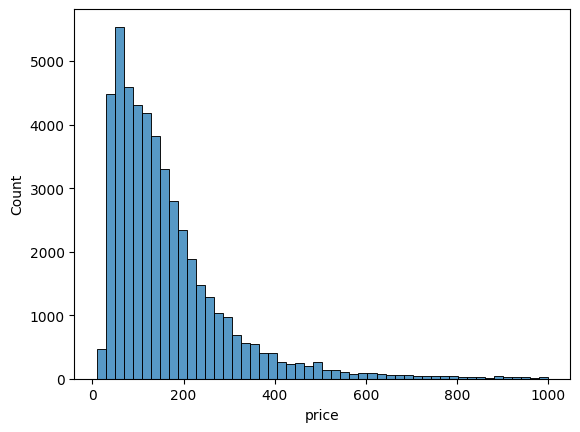

In [12]:
# Visualisoidaan hintojen jakautuminen kohteille, joiden hinnat on alle 1000
sns.histplot(data = data[data["price"] < 1000] , x = "price", bins = 50)

In [9]:
# Katsotaan top 10 kaupunginosat, joissa on eniten kohteita
most_bnbs = data["neighbourhood"].value_counts().head(10)
most_bnbs


neighbourhood
Westminster               6524
Kensington and Chelsea    3684
Camden                    3559
Tower Hamlets             3371
Hackney                   2579
Southwark                 2481
Wandsworth                2372
Lambeth                   2282
Islington                 2263
Hammersmith and Fulham    2149
Name: count, dtype: int64

<Axes: ylabel='neighbourhood'>

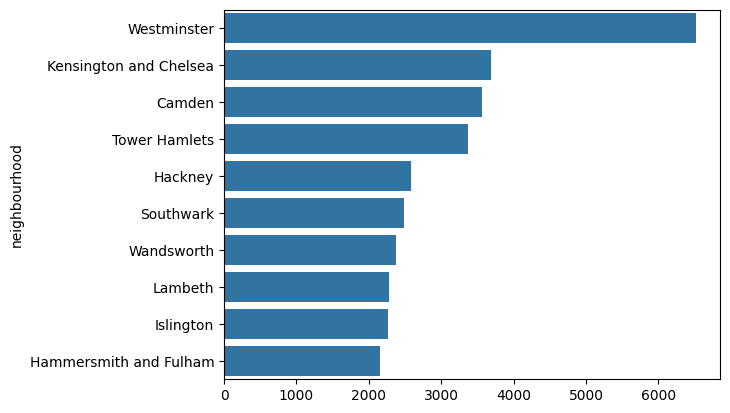

In [10]:
# Visualisoidaan barchartilla
sns.barplot(x = most_bnbs.values, y = most_bnbs.index)